<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/CarterMod04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter,** CSC 162, Fall 2025; December 12, 2025

**Assignment Tasks**



**Threshold Tuning & Analysis**

1. Experiment with conf, iou, and max_det for both detection and segmentation (at least 3 settings each).

2. Create a markdown table summarizing how the number and quality of outputs change.

**Custom Visualization**

*1. Detection:* Draw bounding boxes in at least three custom colors based on class (e.g., red for “person,” blue for “sports ball,” green for “cup”).

*2. Segmentation:* Overlay instance masks at 50% opacity; annotate each mask’s class label and confidence in its top-left corner.

**Output Extraction & Reporting**

*1. Detection:* Build and display a table:

*2. Segmentation*: For each mask, calculate the mask area by summing the binary mask array; report:

*3. Classification*: Generate a Pandas DataFrame of Top-10 classes and their confidences, then display it.

**Instructions**


In this assignment, you will build an end-to-end computer vision pipeline using Ultralytics’ YOLOv8 models to perform object detection, instance segmentation, and image classification on the famous Zidane head-butt photo. You will work entirely in Google Colab, suppress non-critical warnings, tune your inference thresholds, visualize results inline, extract raw outputs, and document your findings.

**Image URL:**

https://ultralytics.com/images/zidane.jpg

**Learning Objectives**
By the end of this assignment, you will be able to:

1. Install and configure YOLOv8 in Google Colab

2. Suppress specific API warnings for cleaner output

3. Load YOLOv8 “nano” variants for detection, segmentation, and classification

4. Run inference with chosen confidence, IoU, and max_det settings

5. Visualize bounding boxes, masks, and labels inline

6. Extract and process raw model outputs (boxes, masks, probabilities)

7. Compute Top-1 and Top-5 class predictions

9. Analyze the effect of threshold tuning on model outputs

**Setup Instructions (Google Colab)**

1. Open a new Google Colab notebook.

2. Rename your notebook to LastNameMod04 in Colab (e.g., SmithMod04).

3. Switch to GPU runtime:

Click Runtime ▶ Change runtime type ▶ GPU ▶ Save.



4. At the top of SmithMod04 (or your LastName), insert and run:

In [ ]:
#python
# Install YOLOv8 & suppress warnings
!pip install -q ultralytics
import warnings
warnings.filterwarnings("ignore")

# Core imports
from ultralytics import YOLO
import torch
import numpy as np

**5. Define the input image URL:**


In [ ]:
#Define the input image URL:

#python
ZIDANE_IMAGE = "https://ultralytics.com/images/zidane.jpg"

**Starter Code Skeleton**
1. Copy this skeleton into your notebook below the setup cells, then implement the missing pieces and customizations.

**1. PART I - OBJECT DETECTION**

In [ ]:
#python
# ──────────────────────────────────────────────────────────────────────────────
# PART 1: OBJECT DETECTION
# ──────────────────────────────────────────────────────────────────────────────
model_det = YOLO("yolov8n.pt")  # nano COCO detector

#show the model's architecture and parameters
model_det.info()                # Optional: view size & layers



YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

**First experiment with conf, iou, max_det.**

In [ ]:
# Run detection; this is running the inference on the image
det_results = model_det.predict(
    source=ZIDANE_IMAGE,
    conf=0.25,
    iou=0.45,
    max_det=50
)



Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 403.8ms
Speed: 36.3ms preprocess, 403.8ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)


**Get the results object.** (first experiment with conf, iou, max_det).

In [ ]:
#get the results object
det_res = det_results[0]


**Display the boxes and confidences and lables on the image.** (first experiment with conf, iou, max_det). Boxes around people are blue and box around tie is yellow. First person confidence is 0.84, next person confidence is 0.82, tie conficence is 0.29.

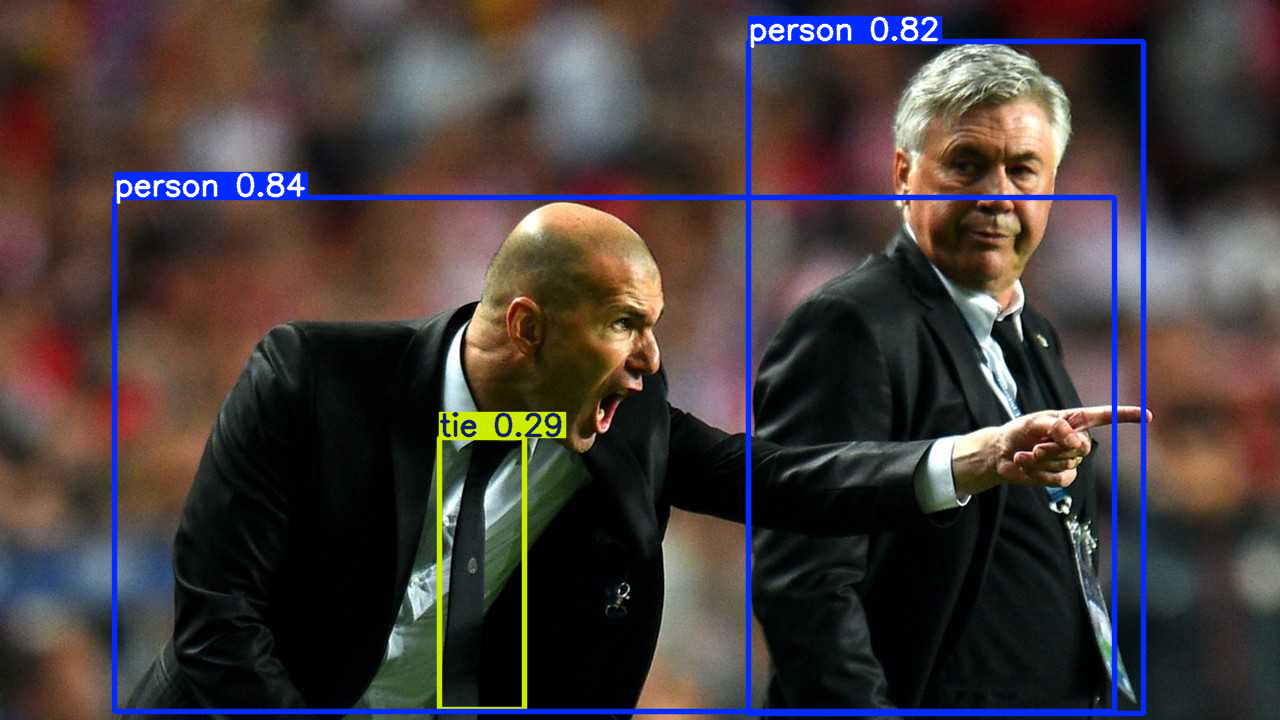

In [ ]:

#Show the boxes and confidences and labels for each person and tie
det_res.show()  # visualize inline

**Extract the confidences for x1, y1, x2, y2 and make a Table - first experiment with conf, iou max_det.** See screenshot below for both people and the tie. The first person has a confidence of 0.84, the second person a confidence of 0.82, and the tie a confidence of 0.29.

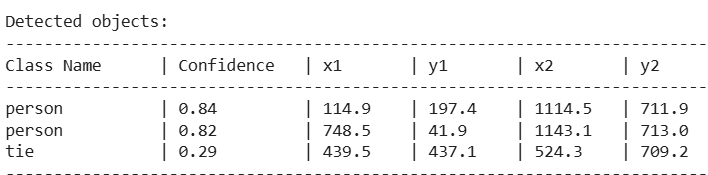

In [ ]:

# TODO: Extract det_res.boxes.xyxy, det_res.boxes.conf, det_res.boxes.cls
#       Print a table of: Class Name | Confidence | x1 | y1 | x2 | y2

# Extract detection details from det_res
bboxes = det_res.boxes.xyxy.tolist()
confidences = det_res.boxes.conf.tolist()
class_ids = det_res.boxes.cls.tolist()

print("\nDetected objects:")
print("-------------------------------------------------------------------------------------------")
print(f"{'Class Name':<15} | {'Confidence':<12} | {'x1':<8} | {'y1':<8} | {'x2':<8} | {'y2':<8}")
print("-------------------------------------------------------------------------------------------")
for bbox, conf, cls_id in zip(bboxes, confidences, class_ids):
    x1, y1, x2, y2 = bbox
    class_name = model_det.names[int(cls_id)]
    print(f"{class_name:<15} | {conf:<12.2f} | {x1:<8.1f} | {y1:<8.1f} | {x2:<8.1f} | {y2:<8.1f}")
print("-------------------------------------------------------------------------------------------")


Detected objects:
-------------------------------------------------------------------------------------------
Class Name      | Confidence   | x1       | y1       | x2       | y2      
-------------------------------------------------------------------------------------------
person          | 0.84         | 114.9    | 197.4    | 1114.5   | 711.9   
person          | 0.82         | 748.5    | 41.9     | 1143.1   | 713.0   
tie             | 0.29         | 439.5    | 437.1    | 524.3    | 709.2   
-------------------------------------------------------------------------------------------


** 2nd experiment with conf, iou, max_det. Values are all higher than first round.**

In [ ]:
# Run detection; this is running the inference on the image
det_results2 = model_det.predict(
    source=ZIDANE_IMAGE,
    conf=0.50,
    iou=0.75,
    max_det=80
)


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 142.9ms
Speed: 3.3ms preprocess, 142.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
# Second experiment with conf, iou, max_det. Get the results object
det_res2 = det_results2[0]


You can see that this time it didn't display the box around the tie with the altered conf, iou, max_det paramenters. Values of iou, conf, and max_det were higher so it detected fewer objects; it is no longer detecting the original tie but it is still detecting the 2 original people. It did't detect any additional objects from the original experiment.

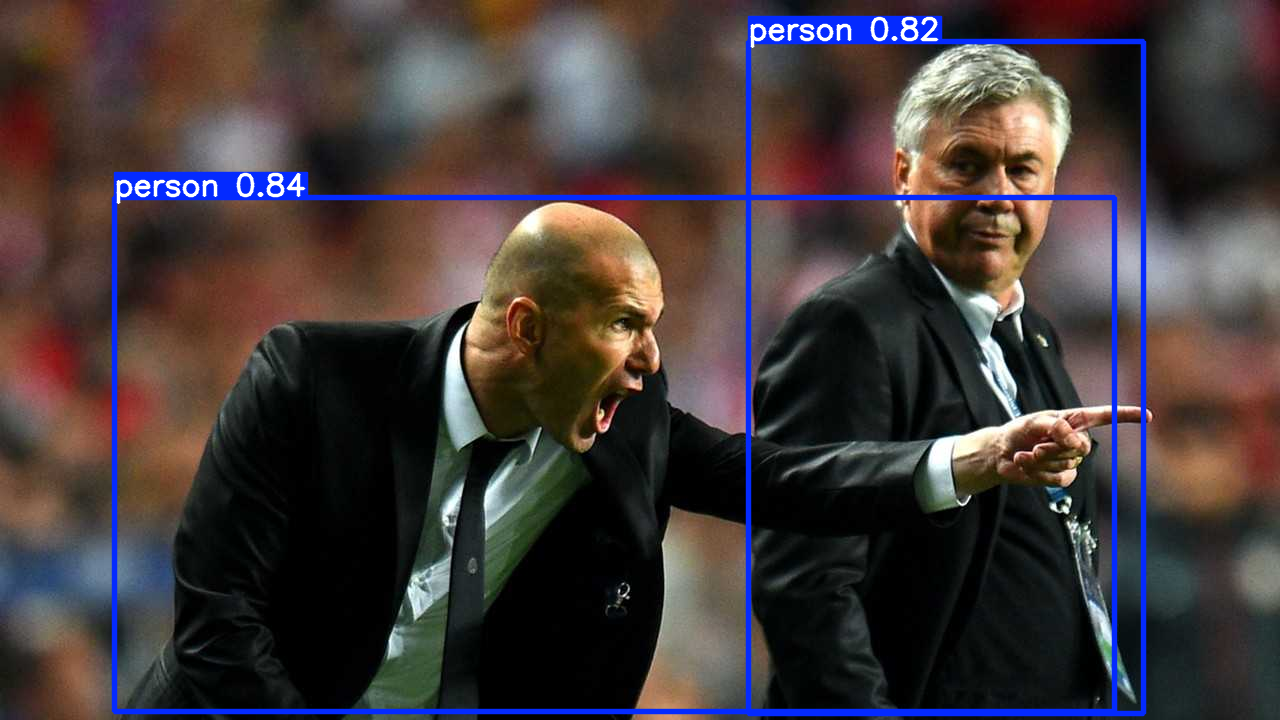

In [ ]:
#SEcond experiment with conf, iou, max_det. Show the boxes and confidences and labels for each person and tie
det_res2.show()  # visualize inline

Confidences for second experimentation looks the same at 0.84, 0.82 for both people and it didn't show the tie since it wasn't detected this round.


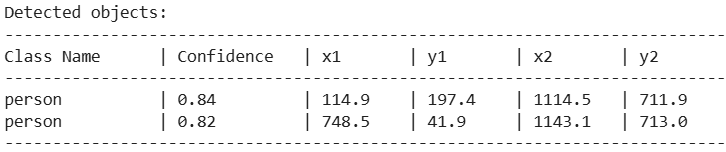

In [ ]:
#Second experiment with conf, iou, max_det
# TODO: Extract det_res.boxes.xyxy, det_res.boxes.conf, det_res.boxes.cls
#       Print a table of: Class Name | Confidence | x1 | y1 | x2 | y2

# Extract detection details from det_res
bboxes = det_res2.boxes.xyxy.tolist()
confidences = det_res2.boxes.conf.tolist()
class_ids = det_res2.boxes.cls.tolist()

print("\nDetected objects:")
print("-------------------------------------------------------------------------------------------")
print(f"{'Class Name':<15} | {'Confidence':<12} | {'x1':<8} | {'y1':<8} | {'x2':<8} | {'y2':<8}")
print("-------------------------------------------------------------------------------------------")
for bbox, conf, cls_id in zip(bboxes, confidences, class_ids):
    x1, y1, x2, y2 = bbox
    class_name = model_det.names[int(cls_id)]
    print(f"{class_name:<15} | {conf:<12.2f} | {x1:<8.1f} | {y1:<8.1f} | {x2:<8.1f} | {y2:<8.1f}")
print("-------------------------------------------------------------------------------------------")


Detected objects:
-------------------------------------------------------------------------------------------
Class Name      | Confidence   | x1       | y1       | x2       | y2      
-------------------------------------------------------------------------------------------
person          | 0.84         | 114.9    | 197.4    | 1114.5   | 711.9   
person          | 0.82         | 748.5    | 41.9     | 1143.1   | 713.0   
-------------------------------------------------------------------------------------------


3rd experiment with conf, iou, max_det. Values are all lower than original first round.

In [ ]:
# Run detection; this is running the inference on the image
det_results3 = model_det.predict(
    source=ZIDANE_IMAGE,
    conf=0.10,
    iou=0.20,
    max_det=15
)



Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 2 ties, 1 tennis racket, 138.8ms
Speed: 2.9ms preprocess, 138.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
# Second experiment with conf, iou, max_det. Get the results object
det_res3 = det_results3[0]

On the 3rd time, there are now 2 ties in yellow (confidences 0.29 and 0.12), 2 people in blue (confidencdes 0.84 and 0.11), and 1 tennis racket in orange (confidence 0.11). Lowering the values for max_det, iou, and conf allowed for more objects to be detected and more boxes and colors. Additional tie and a racket were detected.

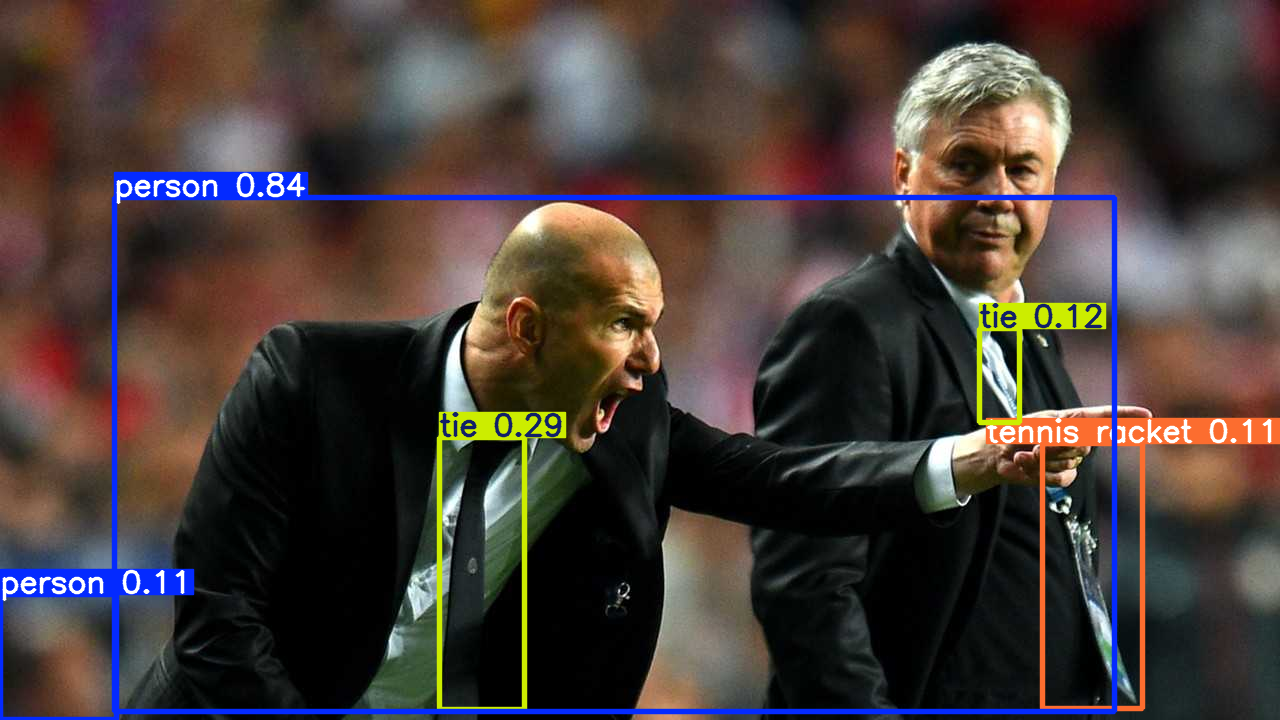

In [ ]:
#3rd experiment with conf, iou, max_det. Show the boxes and confidences and labels for each person and tie
det_res3.show()  # visualize inline

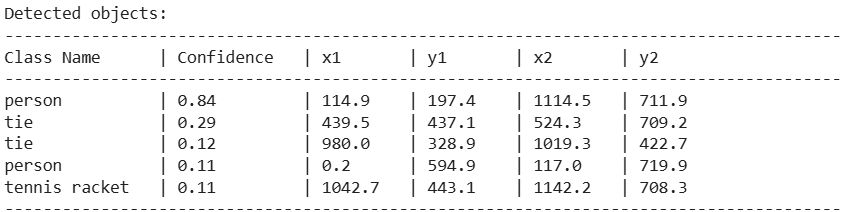

In [ ]:
#3rd experiment with conf, iou, max_det
# TODO: Extract det_res.boxes.xyxy, det_res.boxes.conf, det_res.boxes.cls
#       Print a table of: Class Name | Confidence | x1 | y1 | x2 | y2

# Extract detection details from det_res
bboxes = det_res3.boxes.xyxy.tolist()
confidences = det_res3.boxes.conf.tolist()
class_ids = det_res3.boxes.cls.tolist()

print("\nDetected objects:")
print("-------------------------------------------------------------------------------------------")
print(f"{'Class Name':<15} | {'Confidence':<12} | {'x1':<8} | {'y1':<8} | {'x2':<8} | {'y2':<8}")
print("-------------------------------------------------------------------------------------------")
for bbox, conf, cls_id in zip(bboxes, confidences, class_ids):
    x1, y1, x2, y2 = bbox
    class_name = model_det.names[int(cls_id)]
    print(f"{class_name:<15} | {conf:<12.2f} | {x1:<8.1f} | {y1:<8.1f} | {x2:<8.1f} | {y2:<8.1f}")
print("-------------------------------------------------------------------------------------------")


Detected objects:
-------------------------------------------------------------------------------------------
Class Name      | Confidence   | x1       | y1       | x2       | y2      
-------------------------------------------------------------------------------------------
person          | 0.84         | 114.9    | 197.4    | 1114.5   | 711.9   
tie             | 0.29         | 439.5    | 437.1    | 524.3    | 709.2   
tie             | 0.12         | 980.0    | 328.9    | 1019.3   | 422.7   
person          | 0.11         | 0.2      | 594.9    | 117.0    | 719.9   
tennis racket   | 0.11         | 1042.7   | 443.1    | 1142.2   | 708.3   
-------------------------------------------------------------------------------------------


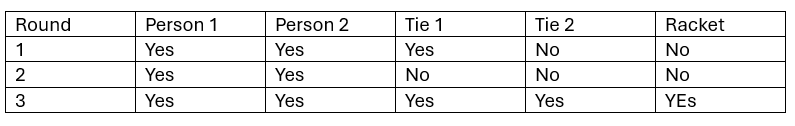

**2. PART II - SEGMENTATION**

In [ ]:
# PART 2: INSTANCE SEGMENTATION
# ──────────────────────────────────────────────────────────────────────────────
#load the segmentation model
model_seg = YOLO("yolov8n-seg.pt")  # nano COCO segmenter

**Run Segmentation**

In [ ]:

# Run segmentation
#    - conf: minimum detection confidence (0.0–1.0)
#    - iou: IoU threshold for non-max suppression (0.0–1.0)
#    - max_det: maximum predictions per image
seg_results = model_seg.predict(
    source=ZIDANE_IMAGE,
    conf=0.25,
    iou=0.45,
    max_det=50
)




Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 282.5ms
Speed: 9.6ms preprocess, 282.5ms inference, 13.9ms postprocess per image at shape (1, 3, 384, 640)


**Get the first results object.**

In [ ]:
#get the first results object
seg_res = seg_results[0]



**Display segmentation masks, bounding boxes, and labels**. Boxes for people are blue and box for tie is yellow. Confidences are displayed (annotated) in top left in addition to the mask's class label (i.e., "person" or "tie"). Overlay instance masks at 50% opacity. (That's why this image appears darker than the original image in the object detection task in Part I above).

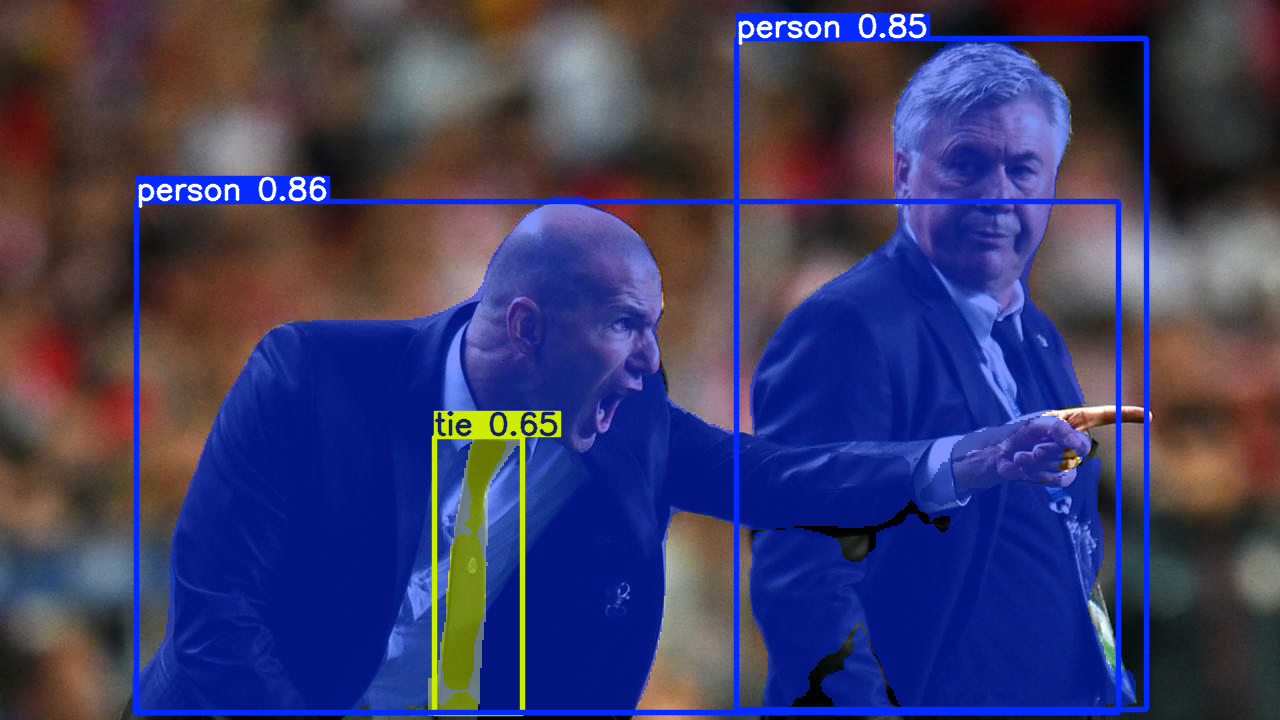

In [ ]:
#Display segmentation masks, bounding boxes, and labels
seg_res.show()      # visualize masks

**Print a list of segmented instances.**

See screenshot below for a Table (of the segmented instances). For each mask, the mask area is calculated by the algorithm by summing the binary mask array.
1. The first person has a confidence of 0.86 with a mask area of 57347.
2. The second person has a confidence of 0.85 with a mask area of 39087.  
3. The tie has a confidence of 0.65 with a mask area of 2776.

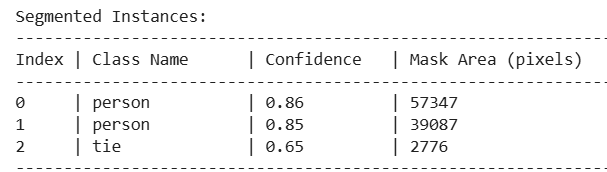

In [ ]:
# Print a list of segmented instances with: Index | Class Name | Confidence | Mask Area (pixels)

seg_masks = seg_res.masks.data
seg_confidences = seg_res.boxes.conf.tolist()
seg_class_ids = seg_res.boxes.cls.tolist()

print("\nSegmented Instances:")
print("-------------------------------------------------------------------------------------------")
print(f"{'Index':<5} | {'Class Name':<15} | {'Confidence':<12} | {'Mask Area (pixels)':<20}")
print("-------------------------------------------------------------------------------------------")

for i, (mask, conf, cls_id) in enumerate(zip(seg_masks, seg_confidences, seg_class_ids)):
    class_name = model_seg.names[int(cls_id)]
    mask_area = mask.sum().item() # Sum of pixels in the mask
    print(f"{i:<5} | {class_name:<15} | {conf:<12.2f} | {mask_area:<20.0f}")
print("-------------------------------------------------------------------------------------------")


Segmented Instances:
-------------------------------------------------------------------------------------------
Index | Class Name      | Confidence   | Mask Area (pixels)  
-------------------------------------------------------------------------------------------
0     | person          | 0.86         | 57347               
1     | person          | 0.85         | 39087               
2     | tie             | 0.65         | 2776                
-------------------------------------------------------------------------------------------


**3. PART III - IMAGE CLASSIFICATION**

**Define the model.**

In [ ]:
# PART 3: IMAGE CLASSIFICATION
# ──────────────────────────────────────────────────────────────────────────────
model_cls = YOLO("yolov8n-cls.pt")  # nano ImageNet classifier



**Run the classification and get the results.**

In [ ]:
# Run classification
cls_results = model_cls.predict(source=ZIDANE_IMAGE)

#get the results of the classificaiton.
cls_res = cls_results[0]




Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 224x224 bow_tie 0.24, cornet 0.10, suit 0.06, stage 0.05, oboe 0.05, 31.0ms
Speed: 33.1ms preprocess, 31.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


**Get the raw probabilities.**

In [ ]:
# Access raw probabilities
raw = getattr(cls_res.probs, "data", cls_res.probs)



**Convert all this to NumPy so we can have array.**

In [ ]:
# Convert to NumPy
if isinstance(raw, torch.Tensor):
    probs = raw.detach().cpu().numpy().flatten()
else:
    probs = np.array(raw).flatten()


In [ ]:
# TODO: Compute Top-1 and Top-5 predictions and print them

# 8. Determine Top-1 prediction
top1_idx  = int(np.argmax(probs))
top1_name = model_cls.names[top1_idx]
top1_conf = probs[top1_idx]


**Determine Top-10 predictions.**

In [ ]:
# 9. Determine Top-10 predictions
top10_idxs = np.argsort(probs)[-10:][::-1]
top10      = [(model_cls.names[i], probs[i]) for i in top10_idxs]


**Display the results of the predictions.**

See a screenshot of the results below. Bow tie was first at 24.11% and whistle was last at 2.62%.

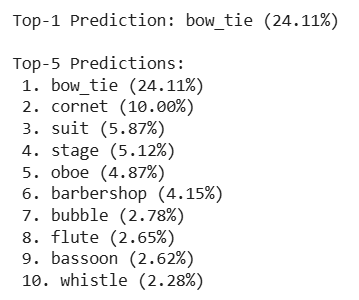

In [ ]:

# 10. Display the results
print(f"\nTop-1 Prediction: {top1_name} ({top1_conf*100:.2f}%)\n")
print("Top-5 Predictions:")
for rank, (name, conf) in enumerate(top10, start=1):
    print(f" {rank}. {name} ({conf*100:.2f}%)")


Top-1 Prediction: bow_tie (24.11%)

Top-5 Predictions:
 1. bow_tie (24.11%)
 2. cornet (10.00%)
 3. suit (5.87%)
 4. stage (5.12%)
 5. oboe (4.87%)
 6. barbershop (4.15%)
 7. bubble (2.78%)
 8. flute (2.65%)
 9. bassoon (2.62%)
 10. whistle (2.28%)
